Exploratory data analysis ( EDA )

In [1]:
%pip install matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/raw/Customer-Churn-Records.csv')
print(df.head(5))

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0

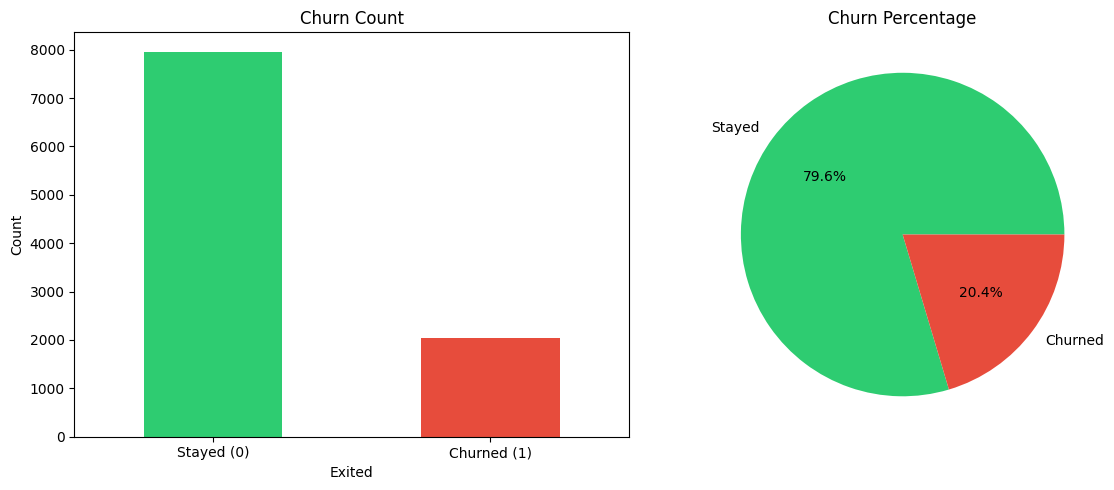

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
df['Exited'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Exited')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)

# Pie chart
df['Exited'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                   autopct='%1.1f%%', labels=['Stayed', 'Churned'])
axes[1].set_title('Churn Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

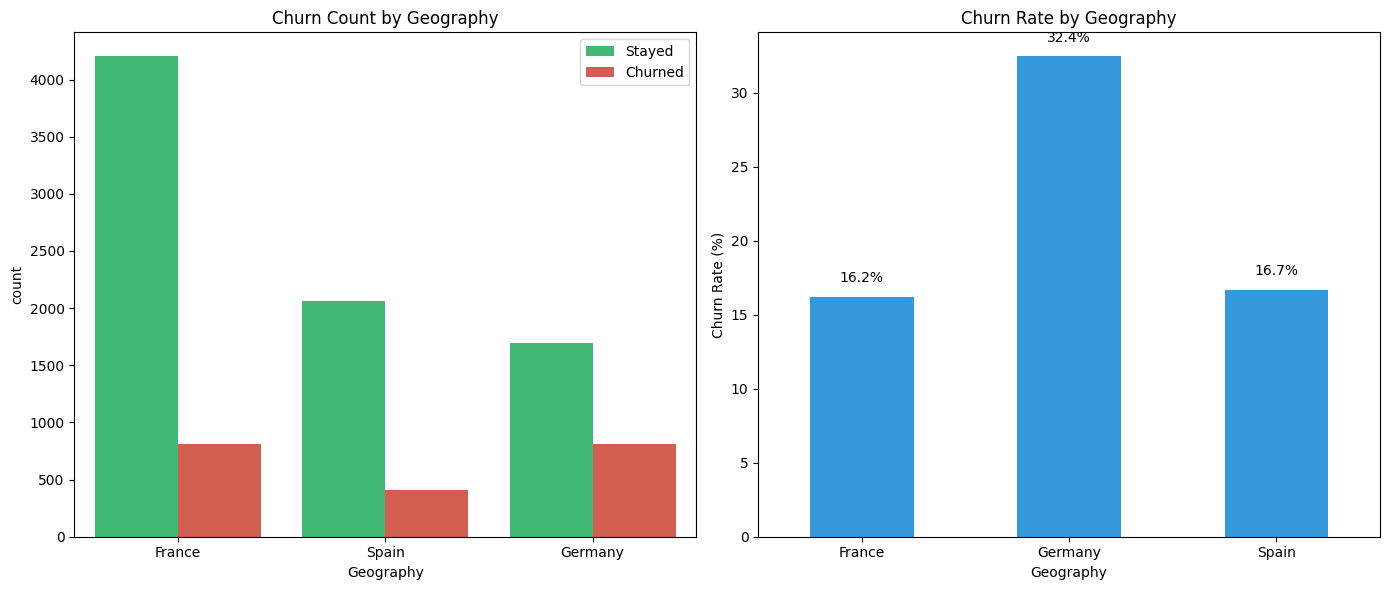

Churn rate by Geography:
Geography
France     16.174711
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count by geography
sns.countplot(data=df, x='Geography', hue='Exited', ax=axes[0], palette=colors)
axes[0].set_title('Churn Count by Geography')
axes[0].legend(['Stayed', 'Churned'])

# Churn rate by geography
churn_by_geo = df.groupby('Geography')['Exited'].mean() * 100
churn_by_geo.plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Churn Rate by Geography')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Add percentage labels on bars
for i, v in enumerate(churn_by_geo):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print("Churn rate by Geography:")
print(churn_by_geo)

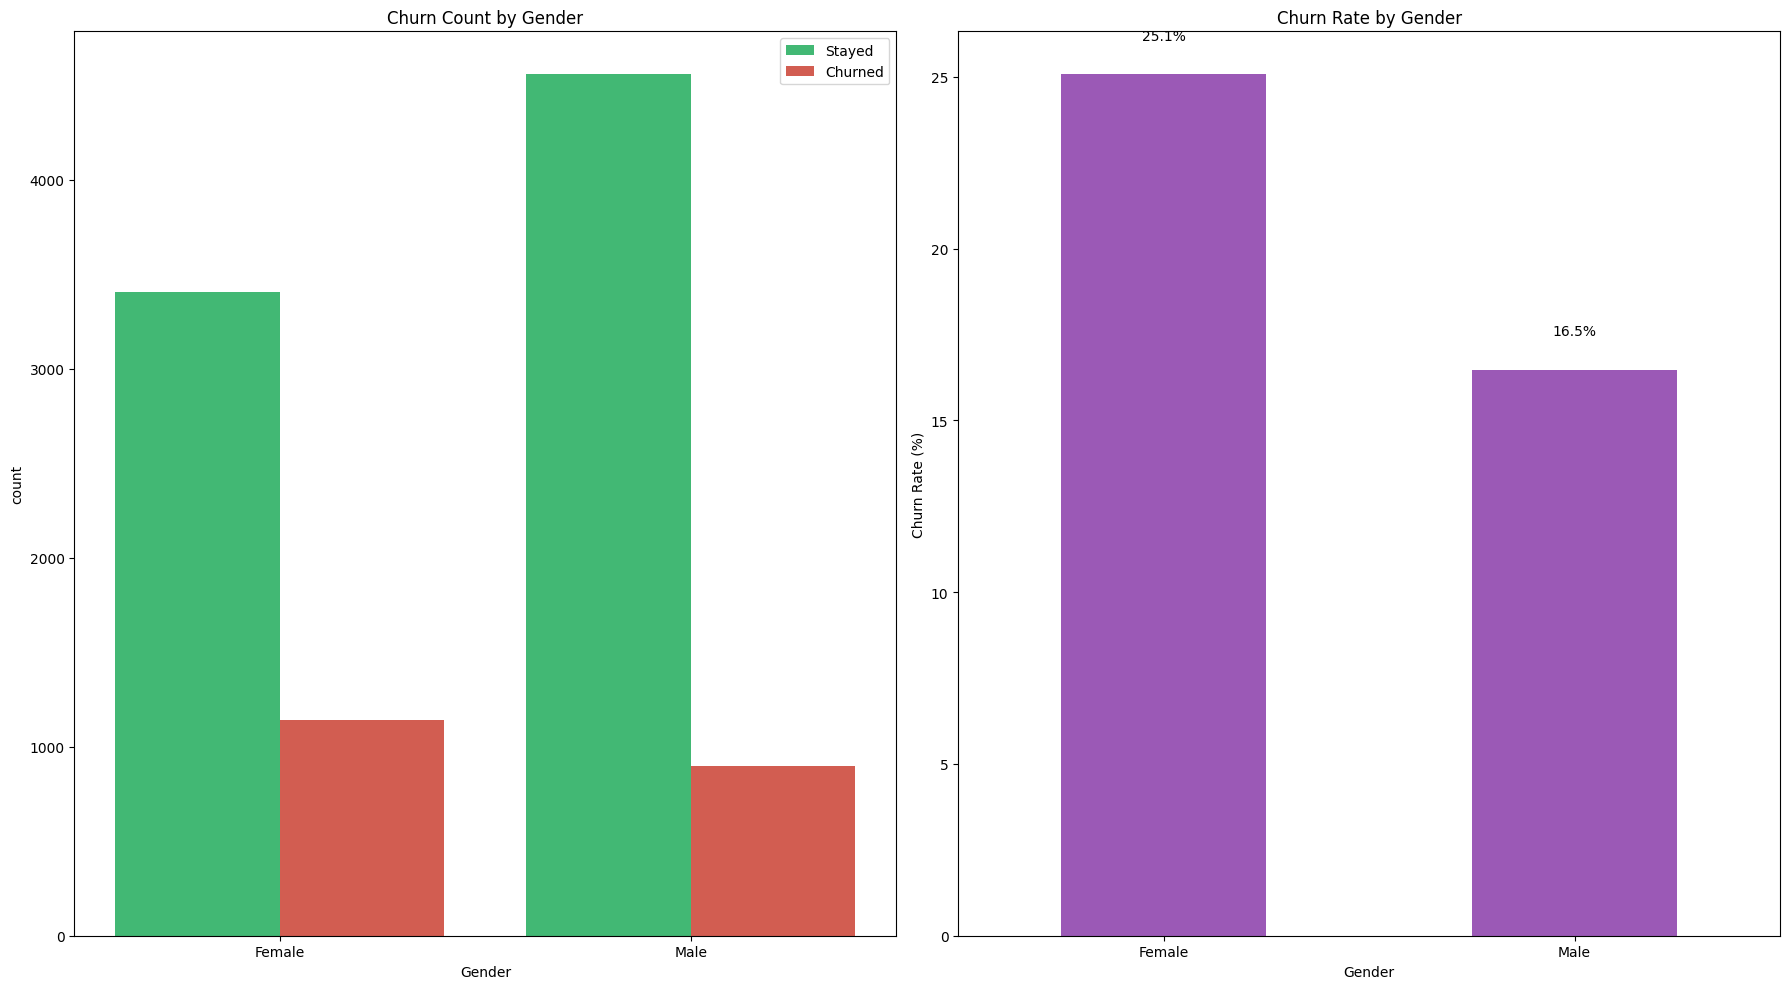

Churn rate by Gender:
Gender
Female    25.071539
Male      16.474253
Name: Exited, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Count by gender
sns.countplot(data=df, x='Gender', hue='Exited', ax=axes[0], palette=colors)
axes[0].set_title('Churn Count by Gender')
axes[0].legend(['Stayed', 'Churned'])

# Churn rate by gender
churn_by_gender = df.groupby('Gender')['Exited'].mean() * 100
churn_by_gender.plot(kind='bar', ax=axes[1], color='#9b59b6')
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(churn_by_gender):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print("Churn rate by Gender:")
print(churn_by_gender)

/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/4128213389.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Age', ax=axes[1], palette=colors)
/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/4128213389.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Stayed', 'Churned'])


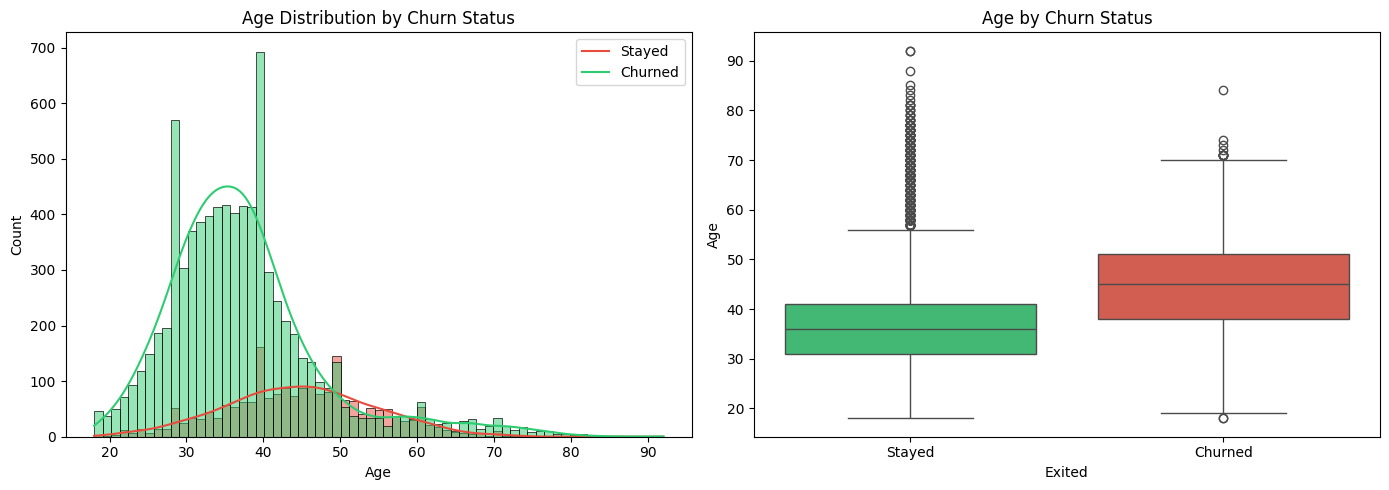

Average age:
Exited
0    37.408063
1    44.835623
Name: Age, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by churn status
sns.histplot(data=df, x='Age', hue='Exited', kde=True, ax=axes[0], palette=colors)
axes[0].set_title('Age Distribution by Churn Status')
axes[0].legend(['Stayed', 'Churned'])

# Box plot of age by churn
sns.boxplot(data=df, x='Exited', y='Age', ax=axes[1], palette=colors)
axes[1].set_title('Age by Churn Status')
axes[1].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

print("Average age:")
print(df.groupby('Exited')['Age'].mean())

/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/1501292917.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='CreditScore', ax=axes[1], palette=colors)
/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/1501292917.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Stayed', 'Churned'])


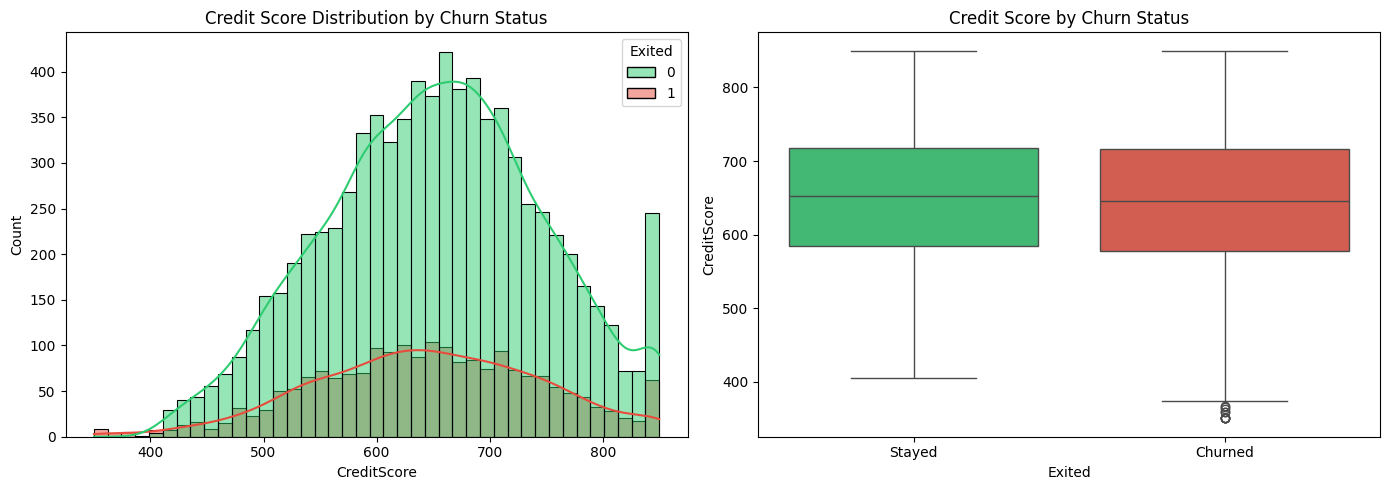

Average credit score:
Exited
0    651.837855
1    645.414622
Name: CreditScore, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit score distribution by churn
sns.histplot(data=df, x='CreditScore', hue='Exited', kde=True, ax=axes[0], palette=colors)
axes[0].set_title('Credit Score Distribution by Churn Status')

# Box plot
sns.boxplot(data=df, x='Exited', y='CreditScore', ax=axes[1], palette=colors)
axes[1].set_title('Credit Score by Churn Status')
axes[1].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

print("Average credit score:")
print(df.groupby('Exited')['CreditScore'].mean())

/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/842452308.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Balance', ax=axes[1], palette=colors)
/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/842452308.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Stayed', 'Churned'])


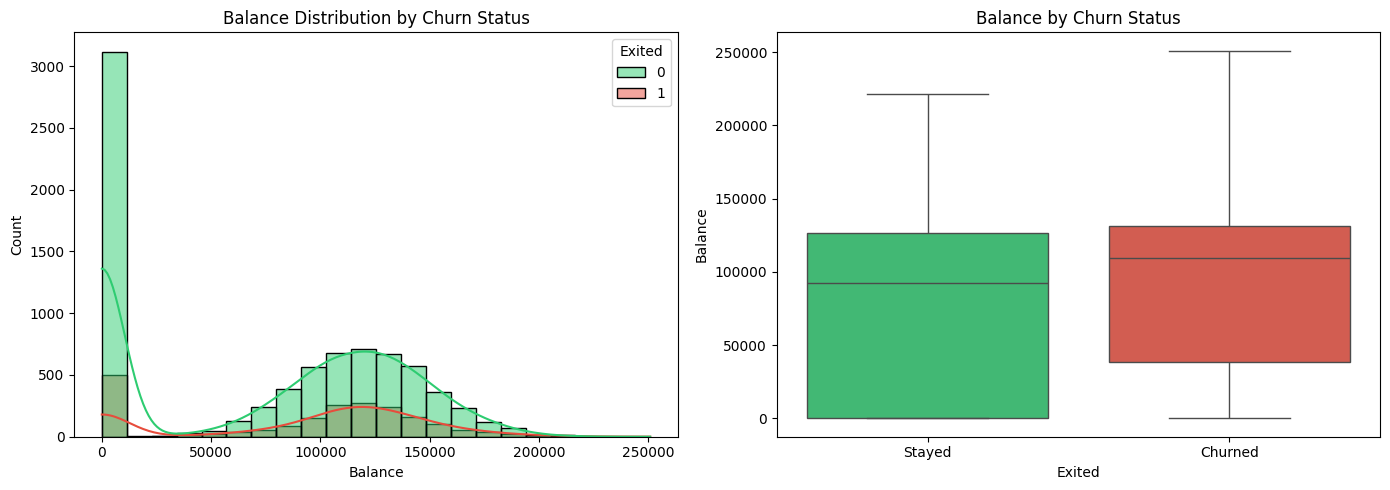

Average balance:
Exited
0    72742.750663
1    91109.476006
Name: Balance, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balance distribution
sns.histplot(data=df, x='Balance', hue='Exited', kde=True, ax=axes[0], palette=colors)
axes[0].set_title('Balance Distribution by Churn Status')

# Box plot
sns.boxplot(data=df, x='Exited', y='Balance', ax=axes[1], palette=colors)
axes[1].set_title('Balance by Churn Status')
axes[1].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

print("Average balance:")
print(df.groupby('Exited')['Balance'].mean())

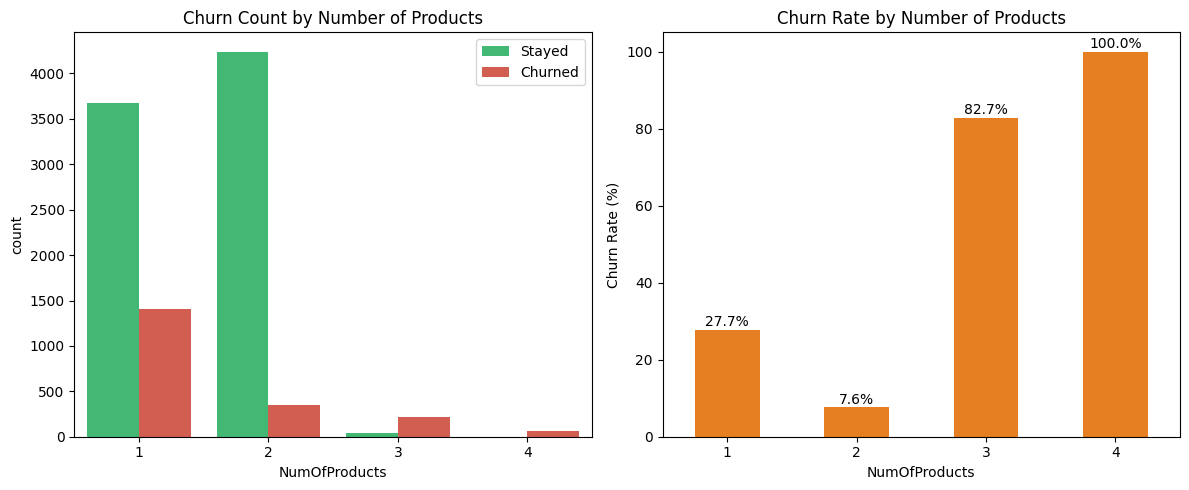

Churn rate by Number of Products:
NumOfProducts
1     27.714398
2      7.603486
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='NumOfProducts', hue='Exited', ax=axes[0], palette=colors)
axes[0].set_title('Churn Count by Number of Products')
axes[0].legend(['Stayed', 'Churned'])

# Churn rate by number of products
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean() * 100
churn_by_products.plot(kind='bar', ax=axes[1], color='#e67e22')
axes[1].set_title('Churn Rate by Number of Products')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(churn_by_products):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print("Churn rate by Number of Products:")
print(churn_by_products)

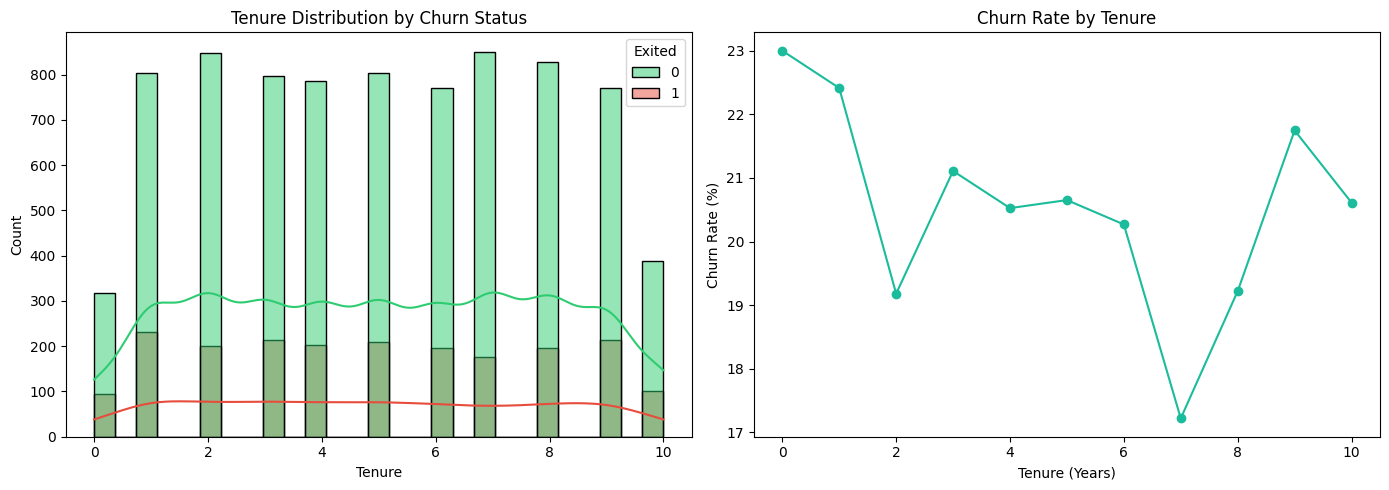

Average tenure:
Exited
0    5.032781
1    4.934740
Name: Tenure, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution
sns.histplot(data=df, x='Tenure', hue='Exited', kde=True, ax=axes[0], palette=colors)
axes[0].set_title('Tenure Distribution by Churn Status')

# Churn rate by tenure
churn_by_tenure = df.groupby('Tenure')['Exited'].mean() * 100
churn_by_tenure.plot(kind='line', ax=axes[1], marker='o', color='#1abc9c')
axes[1].set_title('Churn Rate by Tenure')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Tenure (Years)')

plt.tight_layout()
plt.show()

print("Average tenure:")
print(df.groupby('Exited')['Tenure'].mean())

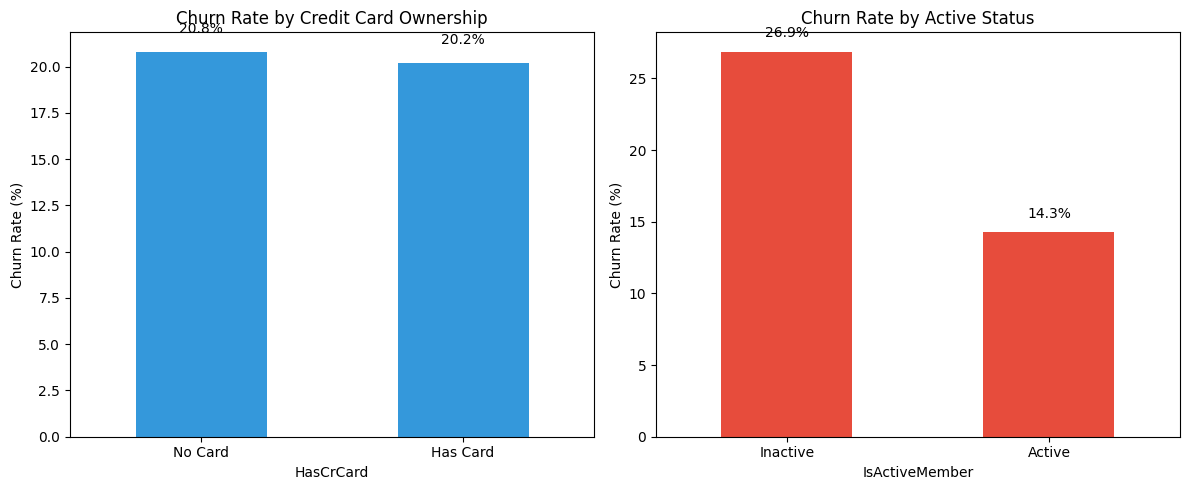

Churn by Credit Card:
HasCrCard
0    20.814941
1    20.198441
Name: Exited, dtype: float64

Churn by Active Status:
IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Has Credit Card
churn_by_card = df.groupby('HasCrCard')['Exited'].mean() * 100
churn_by_card.plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Churn Rate by Credit Card Ownership')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xticklabels(['No Card', 'Has Card'], rotation=0)

for i, v in enumerate(churn_by_card):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')

# Is Active Member
churn_by_active = df.groupby('IsActiveMember')['Exited'].mean() * 100
churn_by_active.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Churn Rate by Active Status')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(['Inactive', 'Active'], rotation=0)

for i, v in enumerate(churn_by_active):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print("Churn by Credit Card:")
print(churn_by_card)
print("\nChurn by Active Status:")
print(churn_by_active)

/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/1325708323.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='EstimatedSalary', ax=axes[1], palette=colors)
/var/folders/0h/jmwkjcc502lfwzlknxf8_bjh0000gp/T/ipykernel_3451/1325708323.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Stayed', 'Churned'])


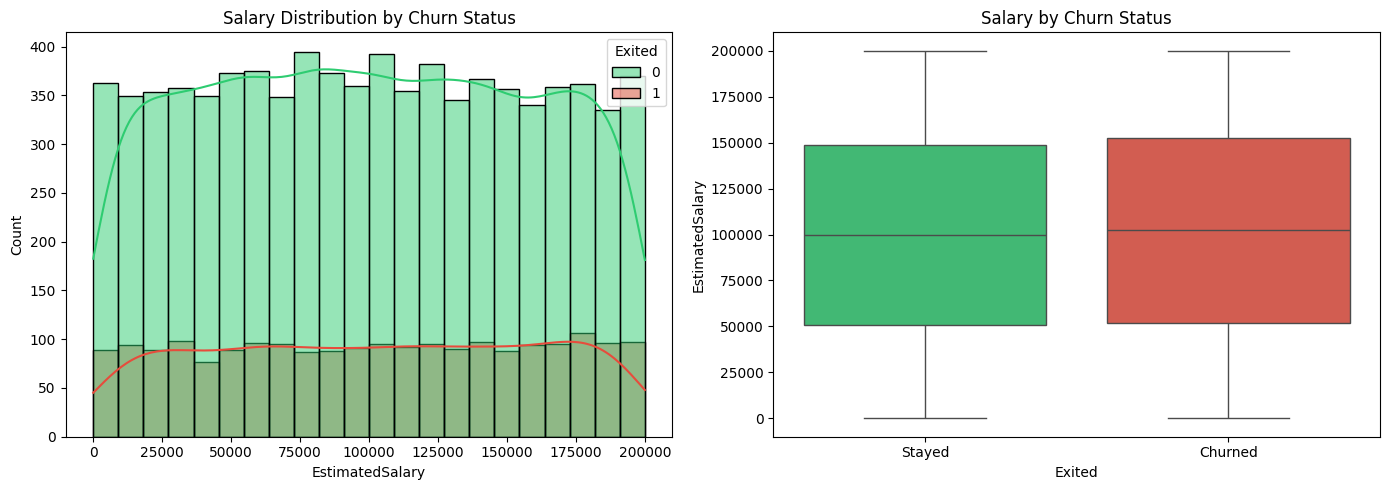

Average salary:
Exited
0     99726.853141
1    101509.908783
Name: EstimatedSalary, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary distribution
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', kde=True, ax=axes[0], palette=colors)
axes[0].set_title('Salary Distribution by Churn Status')

# Box plot
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', ax=axes[1], palette=colors)
axes[1].set_title('Salary by Churn Status')
axes[1].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

print("Average salary:")
print(df.groupby('Exited')['EstimatedSalary'].mean())

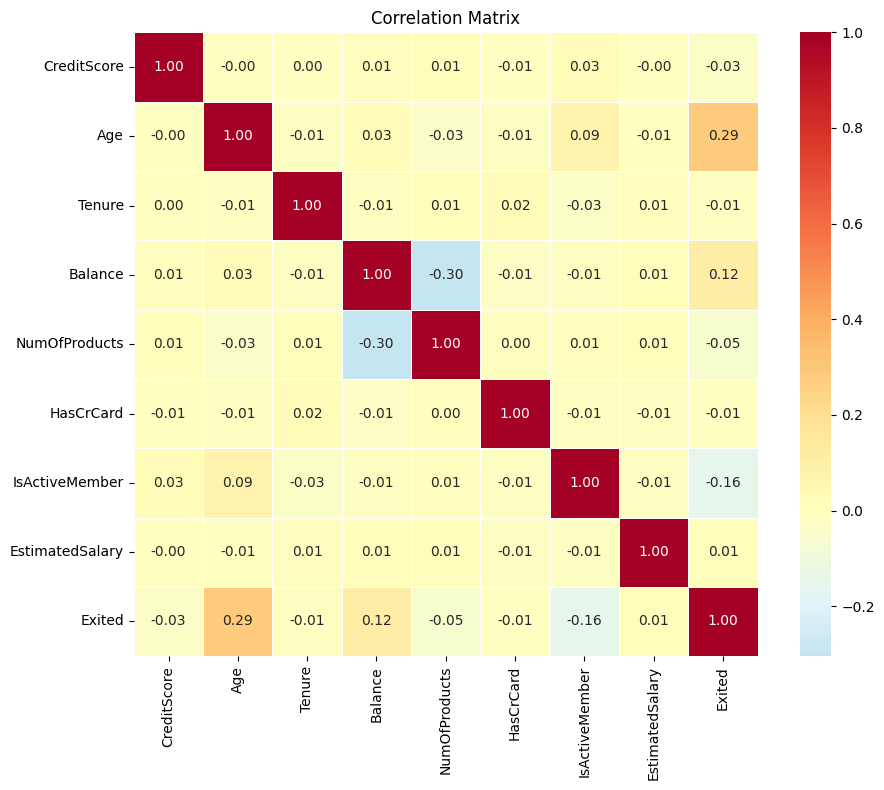

In [12]:
# Select only numerical columns for correlation
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                  'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

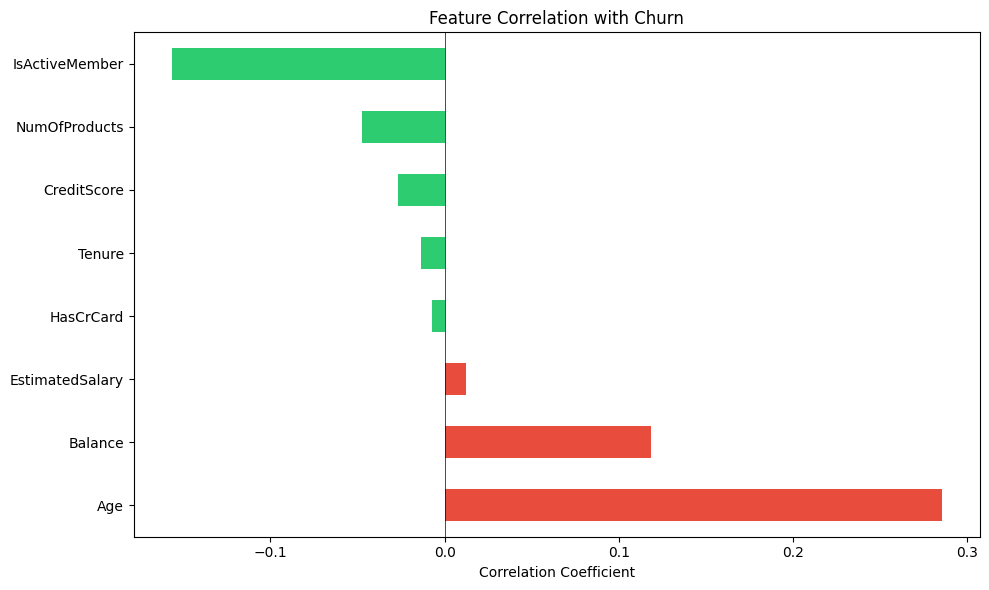

Correlation with Exited:
Age                0.285296
Balance            0.118577
EstimatedSalary    0.012490
HasCrCard         -0.006976
Tenure            -0.013656
CreditScore       -0.026771
NumOfProducts     -0.047611
IsActiveMember    -0.156356
Name: Exited, dtype: float64


In [13]:
target_correlation = df[numerical_cols].corr()['Exited'].drop('Exited').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_corr = ['#e74c3c' if x > 0 else '#2ecc71' for x in target_correlation]
target_correlation.plot(kind='barh', color=colors_corr)
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Correlation with Exited:")
print(target_correlation)

============================================================
EXPLORATORY DATA ANALYSIS - FINAL SUMMARY
============================================================
By the EDA analysis found strong predictors such as Age, Geography,Number of products, Active membership status, Gender, and Balance. 
------------------------------------------
1. Age
- Churned customers average age: ~45 years
- Retained customers average age: ~36 years
- Correlation with churn: 0.29 (strongest)
The older customers are high churn risk
2. Geography
- Germany: 32.4% churn rate (HIGH RISK)
- France: 16.2% churn rate
- Spain: 16.7% churn rate
German market needs targeted retention
3. Number of products
- 1 product: 27.7% churn
- 2 products: 7.6% churn 
- 3 products: 82.7% churn
- 4 products: 100% churn
Cross-sell to reach 2 products, but 3+ is problematic
4. Active memebrship status
- Inactive members: 26.9% churn
- Active members: 14.3% churn
- Correlation with churn: -0.16
The engagement reduces churn significantly
5. Gender
- Female: 25.1% churn
- Male: 16.5% churn
Female customers need more attention
6. Balance
- Churned customers have higher average balance
- Many retained customers have zero balance
- Correlation with churn: 0.12
High-balance customers may feel underserved